In [1]:
#%matplotlib notebook
import numpy  as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
q = 1.60217662E-19  #elementary charge C
m = 9.10938356E-31 # electron mass kg
pi = np.pi

def bfield_from_ECR(frequency):
    B_field = (1E9*2*pi*m*frequency)/q
    return B_field

def freq_from_bfield(B):
    freq = (q*B)/(1E9*2*pi*m)
    return freq

def format_plot(xlabel,ylabel, title):
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel(xlabel,fontsize=20)
    plt.ylabel(ylabel,fontsize=20)
    plt.title(title, fontsize = 22)
    plt.ticklabel_format(useOffset=False)
    #plt.legend(fontsize = 16)

## Magnet Configuration

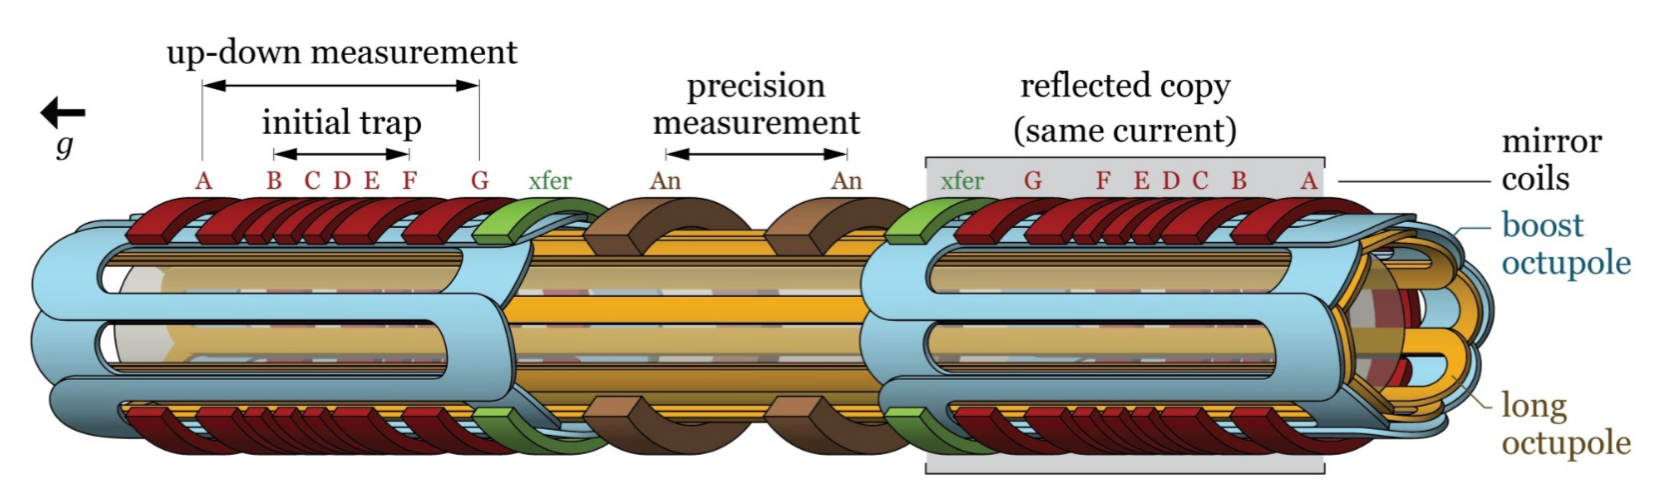



## 2D Model 

In [3]:
#some of the files are in the original folder but I made a new one for the magnets I added
path1 = 'Bfield_calculator_outputs/'
path2 = 'Bfield_calculator_outputs/Top Magnets/'

filename = path1 + "Babcock_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Position = np.array(data[:,0])*10
#Position = [p + 671-342.5+1 for p in Position] #matches positions to sequencer
Babcock_2D = np.array(data[:,1]) 


filename = path1 + "Babcock_shim_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Babcock_2D_shim = np.array(data[:,1]) 


filename = path1 + "MAGB_1A" #MaB in series with MgB
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
MirA_2D = np.array(data[:,1])


filename = path1 + "SOB_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
SoB_2D = np.array(data[:,1])


filename = path1 + "LOCT_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
LoC_2D = np.array(data[:,1])


filename = path1 + "OCT_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Oc_2D = np.array(data[:,1])

filename = path2 + "tickle"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
tickle = np.array(data[:,1])

filename = path2 + 'MB_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_B = np.array(data[:,1])

filename = path2 + 'MC_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_C = np.array(data[:,1])

filename = path2 + 'MD_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_D = np.array(data[:,1])

filename = path2 + 'ME_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_E = np.array(data[:,1])

filename = path2 + 'MF_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_F = np.array(data[:,1])

filename = path2 + 'MA_T_1A'  #MaT in series with MgT
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_AT = np.array(data[:,1])

filename = path2 + 'MbT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_bT = np.array(data[:,1])

filename = path2 + 'McT'  
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_cT = np.array(data[:,1])

filename = path2 + 'MdT'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_dT = np.array(data[:,1])

filename = path2 + 'MeT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_eT = np.array(data[:,1])*2

filename = path2 + 'MfT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_fT = np.array(data[:,1])

filename = path2 + 'OcT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Octupole_B = np.array(data[:,1])

#this will calculate the B field given some currents
def field_2D_calculation(current):
    return Babcock_2D*current[0] + MirA_2D*current[1]  + SoB_2D*current[2] + LoC_2D*current[3] + Oc_2D*current[4] + tickle*current[5] + Babcock_2D_shim*current[6] + Mirror_B*current[7] + Mirror_C*current[8] + Mirror_D*current[9] + Mirror_E*current[10] + Mirror_F*current[11] + Mirror_AT*current[12] + Mirror_bT*current[13] + Mirror_cT*current[14] + Mirror_dT*current[15] + Mirror_eT*current[16] + Mirror_fT*current[17] + Octupole_B*current[18]


In [4]:
list_stringa = ["PreGravity_20mT_well", "GravityRelease_17mT_well" ,"GravityRelease_5mT_well", "GravityRelease_2p5mT_well"] 
list_MB      = [3.4702, 2.9122, 0.9416, 0.5328]
#list_targets = [-1.25, -0.75, -0.5, -0.375, -0.25, 0, 0.25, 0.5, 0.75, 1.25]
list_targets = [+0.1, -0.1]

In [5]:
Zmin                 = -0.605  # m
Zmax                 = -0.481  # m
Zmid                 = -0.5434 # m
zacceptance_min      = -0.775  # m
zacceptance_max      = -0.325  # m

In [6]:
#magnet currents
B = 191 
BS = 5
MA = 0.39 #in series with MG
tickle_g = 0 
LOc = 0
Oc = 220
SB = 0

MB = 0.9416
MF = MB 

MC = 0.2767
MD = 0.2802
ME = 0.2907

MAT = 0 #in series with MGT
MbT = 0
McT = 0
MdT = 0
MeT = 0
MfT = 0

OcT = 0

currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
#currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]

field_2D = field_2D_calculation(currents)
field_2D = field_2D/1e4

In [7]:
import optuna

def compute_bias_from_delta(delta: float) -> float:
    MF = MB - delta

    currents = [B, MA, SB, LOc, Oc, tickle_g, BS,
                MB, MC, MD, ME, MF,
                0, MbT, McT, MdT, MeT, MfT, OcT]

    field_2D = field_2D_calculation(currents) / 1e4

    index_mid = np.argmin(np.abs(Position - Zmid * 1e3))
    bias_g = -(np.max(field_2D[:index_mid]) - np.max(field_2D[index_mid:])) * 1e4 / 2.2
    return float(bias_g)

def objective(trial: optuna.Trial) -> float:
    # range di ricerca: scegli tu (importante!)
    delta = trial.suggest_float("delta_MB_minus_MF", -0.5, 0.5)  # esempio 0..0.2 A
    bias = compute_bias_from_delta(delta)

    # Minimizza l’errore rispetto al target
    err = abs(bias - BIAS_TARGET)

    # (opzionale) salva valori utili nei risultati
    trial.set_user_attr("bias", bias)
    trial.set_user_attr("MF", MB - delta)

    return err

# Save the Magnetic field Map 

In [8]:
# Save the file in Folder
# z (mm) - Bz on axis,Total potential (T) - Bz on axis,z (mm) - Min |B| on wall,Total potential (T) - Min |B| on wall

def save_file(BIAS_G, Position, field_2D):
    dtype = [
        ('z_mm__Bz_on_axis', 'f8'),
        ('Total_potential_T__Bz_on_axis', 'f8'),
    ]
    
    print(dtype[0][0])
    
    N = len(Position)
    data_new = np.empty(N, dtype=dtype)
    print(type(Position))
    
    data_new['z_mm__Bz_on_axis'] = [p for p in Position]
    data_new['Total_potential_T__Bz_on_axis'] = field_2D
    
    out_file = f"../toy/Bfield_notebook/{stringa}_{(str(round(BIAS_G,2)).replace('.','p') + 'g')}.csv"
    print(dtype[0][0] + dtype[1][0])
    
    header = dtype[0][0] + "," + dtype[1][0]
    
    np.savetxt(
        out_file,
        data_new,
        delimiter=",",
        header=header,
        comments=''   # IMPORTANTISSIMO: evita il "#"
    )

In [9]:
TOL = 1e-3  # millesimo (stessa unità del tuo bias)

def stop_when_good_enough(study: optuna.Study, trial: optuna.Trial):
    if study.best_value is not None and study.best_value <= TOL:
        study.stop()

list_biases = []
for stringa, current in zip(list_stringa,list_MB):
    MB  = current
    for bias in list_targets:
        BIAS_TARGET = bias
    
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials = 300, callbacks=[stop_when_good_enough])
        
        best = study.best_trial
        best_delta = best.params["delta_MB_minus_MF"]
        best_MF = MB - best_delta
        best_bias = best.user_attrs["bias"]
        
        print("Best delta (MB - MF) =", best_delta)
        print("Best MF =", best_MF)
        print("Bias ottenuto =", best_bias)
        print("Errore =", best.value)
    
        MF = MB - best_delta
    
        currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
        #currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]
        
        field_2D = field_2D_calculation(currents)
        field_2D = field_2D/1e4
        BIAS_G = compute_bias_from_delta(best_delta)
        
        save_file(BIAS_G, Position, field_2D )
        list_biases.append((str(round(BIAS_G,2)).replace('.','p') + 'g'))
print( list(set(list_biases)))

[I 2026-02-17 10:41:33,456] A new study created in memory with name: no-name-830c2f1e-842f-449a-90a9-1ab1ad4f293e
[I 2026-02-17 10:41:33,461] Trial 0 finished with value: 10.899783958257625 and parameters: {'delta_MB_minus_MF': 0.2617217118813032}. Best is trial 0 with value: 10.899783958257625.
[I 2026-02-17 10:41:33,463] Trial 1 finished with value: 23.252048693651854 and parameters: {'delta_MB_minus_MF': -0.48112500848702433}. Best is trial 0 with value: 10.899783958257625.
[I 2026-02-17 10:41:33,466] Trial 2 finished with value: 0.6103385603192042 and parameters: {'delta_MB_minus_MF': 0.03791290940288927}. Best is trial 2 with value: 0.6103385603192042.
[I 2026-02-17 10:41:33,468] Trial 3 finished with value: 4.436785833100041 and parameters: {'delta_MB_minus_MF': -0.07186860191911304}. Best is trial 2 with value: 0.6103385603192042.
[I 2026-02-17 10:41:33,471] Trial 4 finished with value: 4.7686433311371434 and parameters: {'delta_MB_minus_MF': -0.07908693355475438}. Best is trial

Best delta (MB - MF) = 0.024758323700968702
Best MF = 3.4454416762990316
Bias ottenuto = 0.0944338606645445
Errore = 0.005566139335455508
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-17 10:41:35,396] Trial 35 finished with value: 6.041577777771297 and parameters: {'delta_MB_minus_MF': -0.10242465141536153}. Best is trial 17 with value: 0.07599417644544665.
[I 2026-02-17 10:41:35,401] Trial 36 finished with value: 14.377790299721232 and parameters: {'delta_MB_minus_MF': 0.34172312721082915}. Best is trial 17 with value: 0.07599417644544665.
[I 2026-02-17 10:41:35,407] Trial 37 finished with value: 3.4088846945952063 and parameters: {'delta_MB_minus_MF': -0.04516015722239408}. Best is trial 17 with value: 0.07599417644544665.
[I 2026-02-17 10:41:35,412] Trial 38 finished with value: 4.296829708961583 and parameters: {'delta_MB_minus_MF': 0.12244914009172966}. Best is trial 17 with value: 0.07599417644544665.
[I 2026-02-17 10:41:35,418] Trial 39 finished with value: 0.2470290636752405 and parameters: {'delta_MB_minus_MF': 0.034360715726366585}. Best is trial 17 with value: 0.07599417644544665.
[I 2026-02-17 10:41:35,423] Trial 40 finished with value: 8.2514

Best delta (MB - MF) = 0.028842426783537867
Best MF = 3.4413575732164623
Bias ottenuto = -0.09332978045445921
Errore = 0.006670219545540798
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-17 10:41:36,995] Trial 35 finished with value: 8.259719413517853 and parameters: {'delta_MB_minus_MF': -0.16017461935089491}. Best is trial 22 with value: 0.1951208011283477.
[I 2026-02-17 10:41:37,000] Trial 36 finished with value: 15.559663837373446 and parameters: {'delta_MB_minus_MF': 0.3580799207606869}. Best is trial 22 with value: 0.1951208011283477.
[I 2026-02-17 10:41:37,005] Trial 37 finished with value: 2.031785936519061 and parameters: {'delta_MB_minus_MF': -0.024708976695209474}. Best is trial 22 with value: 0.1951208011283477.
[I 2026-02-17 10:41:37,011] Trial 38 finished with value: 5.748791032896977 and parameters: {'delta_MB_minus_MF': -0.10555866560001441}. Best is trial 22 with value: 0.1951208011283477.
[I 2026-02-17 10:41:37,016] Trial 39 finished with value: 5.26138111496483 and parameters: {'delta_MB_minus_MF': 0.13392687984909296}. Best is trial 22 with value: 0.1951208011283477.
[I 2026-02-17 10:41:37,021] Trial 40 finished with value: 9.441048597493

...

Best delta (MB - MF) = 0.005949380817332135
Best MF = 0.9356506191826679
Bias ottenuto = -0.09306044572216458
Errore = 0.006939554277835422
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-17 10:41:42,853] Trial 38 finished with value: 2.404869021963623 and parameters: {'delta_MB_minus_MF': -0.05521264998734577}. Best is trial 24 with value: 0.14951399537822346.
[I 2026-02-17 10:41:42,857] Trial 39 finished with value: 9.601819980208623 and parameters: {'delta_MB_minus_MF': 0.23404830731693124}. Best is trial 24 with value: 0.14951399537822346.
[I 2026-02-17 10:41:42,861] Trial 40 finished with value: 15.130454886024218 and parameters: {'delta_MB_minus_MF': -0.33381371375941626}. Best is trial 24 with value: 0.14951399537822346.
[I 2026-02-17 10:41:42,866] Trial 41 finished with value: 2.470130734098013 and parameters: {'delta_MB_minus_MF': -0.05664087566339687}. Best is trial 24 with value: 0.14951399537822346.
[I 2026-02-17 10:41:42,872] Trial 42 finished with value: 0.053419783418843014 and parameters: {'delta_MB_minus_MF': -0.003740682277923792}. Best is trial 42 with value: 0.053419783418843014.
[I 2026-02-17 10:41:42,877] Trial 43 finished with value: 5.

Best delta (MB - MF) = -0.00271004743964604
Best MF = 0.5355100474396461
Bias ottenuto = 0.10637411106305772
Errore = 0.006374111063057714
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-17 10:41:44,398] Trial 39 finished with value: 6.065414299285178 and parameters: {'delta_MB_minus_MF': 0.13578845632435435}. Best is trial 31 with value: 0.1104944504416844.
[I 2026-02-17 10:41:44,403] Trial 40 finished with value: 3.3272320431445856 and parameters: {'delta_MB_minus_MF': 0.07501653956977572}. Best is trial 31 with value: 0.1104944504416844.
[I 2026-02-17 10:41:44,408] Trial 41 finished with value: 0.9232613069558674 and parameters: {'delta_MB_minus_MF': 0.02203700277903011}. Best is trial 31 with value: 0.1104944504416844.
[I 2026-02-17 10:41:44,413] Trial 42 finished with value: 0.06918453927816656 and parameters: {'delta_MB_minus_MF': 0.0033266469215448577}. Best is trial 42 with value: 0.06918453927816656.
[I 2026-02-17 10:41:44,419] Trial 43 finished with value: 0.40754330352448753 and parameters: {'delta_MB_minus_MF': 0.010739110444896527}. Best is trial 42 with value: 0.06918453927816656.
[I 2026-02-17 10:41:44,425] Trial 44 finished with value: 7.8458

Best delta (MB - MF) = 0.0018193809950581364
Best MF = 0.5309806190049419
Bias ottenuto = -0.10038195634821566
Errore = 0.0003819563482156535
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis
['-0p09g', '0p11g', '-0p1g', '0p09g']


In [10]:
MF = MB - best_delta

currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
#currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]

field_2D = field_2D_calculation(currents)
field_2D = field_2D/1e4

## Plotting

In [11]:
# Compute Bias
index_mid = np.argmin(np.abs(Position - Zmid*1e3)) # index relative to the potential well center
print(Position[index_mid])
Bottom_Well = (field_2D)[index_mid]

massimo = np.max((field_2D)[:index_mid]); 
BIAS_G = (np.max((field_2D)[:index_mid]) - np.max((field_2D)[index_mid:]))*1e4/2.2
print(BIAS_G)

-543.4000000000001
0.10038195634821566


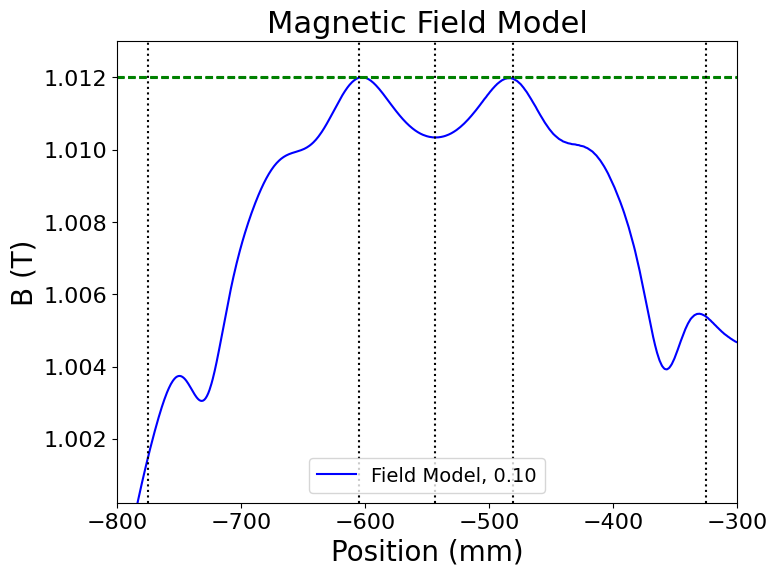

In [12]:
plt.figure(figsize=(8,6))
plt.plot([p for p in Position], field_2D, 'b', label = f'Field Model, {BIAS_G:.2f}')

plt.ylim(Bottom_Well*0.99, massimo*1.001)
plt.xlim( -800, -300)

plt.axhline(np.max((field_2D)[:index_mid]), linestyle = "--", color = "green")
plt.axhline(np.max((field_2D)[index_mid:]), linestyle = "--", color = "green")
plt.axvline(Zmin*1e3, color = "black", linestyle = "dotted")
plt.axvline(Zmax*1e3, color = "black", linestyle = "dotted")
plt.axvline(Zmid*1e3, color = "black", linestyle = "dotted")
plt.axvline(zacceptance_min*1e3, color = "black", linestyle = "dotted")
plt.axvline(zacceptance_max*1e3, color = "black", linestyle = "dotted")
plt.legend(fontsize = 14, loc = "lower center")
format_plot('Position (mm)', 'B (T)', 'Magnetic Field Model')

In [13]:
# plt.figure(figsize = (8,6))

# plt.plot(Position, [freq_from_bfield(b/1e4) for b in field_2D], color = 'k', label = 'Field Model')

# format_plot('Position (mm)', 'Frequency (GHz)', '')